In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)

In [2]:
data = {
    "temperature": [10, 15, 22, 25, 28, 35, 38],
    "humidity":    [30, 40, 50, 55, 60, 70, 80],
    "y":           [ 0,  0,  1,  1,  1,  0,  0],
}

df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,22,50,1
3,25,55,1
4,28,60,1
5,35,70,0
6,38,80,0


In [3]:
# X_raw:
# pandas DataFrame 에서 입력 컬럼(온도, 습도)만 꺼내 (n, 2) NumPy 배열로 바꿉니다.
# 아직 정규화도 하지 않았고, PyTorch Tensor도 아닙니다.
X_raw = df[["temperature", "humidity"]].to_numpy(dtype=np.float32)

# y:
# 현재 노트북에서 사용 중인 정답 컬럼 "y"를 그대로 사용합니다.
# 정답도 우선 NumPy 배열 형태로 중비합니다. reshape(-1, 1)의 -1은 "행 수는 자동 계산".
y = df["y"].to_numpy(dtype=np.float32).reshape(-1, 1)

In [4]:
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)
X_norm = (X_raw - X_mean) / X_std
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

In [5]:
class SimpleMLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_layer = torch.nn.Linear(2, 2)
        self.output_layer = torch.nn.Linear(2, 1)
    
    def forward(self, X):
        H_hidden = self.hidden_layer(X)
        z_hidden = torch.sigmoid(H_hidden)
        H_output = self.output_layer(z_hidden)
        return H_output

In [6]:
torch.manual_seed(42)
model = SimpleMLP()
print(model)

SimpleMLP(
  (hidden_layer): Linear(in_features=2, out_features=2, bias=True)
  (output_layer): Linear(in_features=2, out_features=1, bias=True)
)


In [7]:
# 이전 Linear/optimizer 방식에서는 직접 만든 bce_cost_torch()함수를 사용했습니다.
# 이번 Module/BCEWithLogitsLoss 방식에서는 직접 BCE 함수를 만들지 않고,
# sigmoid + BCE계산을 함께 처리하는 BCEWithLogitsLoss 를 사용합니다.
cost_fn = torch.nn.BCEWithLogitsLoss()

print(cost_fn)

BCEWithLogitsLoss()


In [8]:
# 학습 전에 순전파를 한 번 실행해서 shape와 cost를 확인합니다. (확인용)

# H_output = model(X_tensor):
# model(X_tensor)를 호출하면 내부에서 forward()가 실행됩니다.
# forward() 안에서 hidden_layer -> sigmoid -> output_layer 계산이 수행되고,
# sigmoid를 적용하지 않은 H_output(logit)을 돌려줍니다.
H_output = model(X_tensor)

# cost_fn(H_output, y_tensor):
# BCEWithLogitsLoss는 내부에서 sigmoid + BCE를 처리하므로,
# 여기서는 sigmoid를 직접 적용하지 않고 H_output을 그대로 넣습니다.
# H_output과 y_tensor의 shape는 같아야 합니다. (둘 다 (n, 1))
cost = cost_fn(H_output, y_tensor)

# z_output은 사람이 보기 위한 예측확률 확인용입니다.(학습 Cost 계산에는 쓰지 않습니다.)
z_output = torch.sigmoid(H_output)

print("H_output:", H_output)
print("y_tensor", y_tensor)
print("z_output:", z_output)
print("initial cost:", cost.item())

H_output: tensor([[0.7248],
        [0.7247],
        [0.6993],
        [0.6850],
        [0.6698],
        [0.6378],
        [0.6379]], grad_fn=<AddmmBackward0>)
y_tensor tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.]])
z_output: tensor([[0.6737],
        [0.6736],
        [0.6680],
        [0.6649],
        [0.6615],
        [0.6543],
        [0.6543]], grad_fn=<SigmoidBackward0>)
initial cost: 0.7983762621879578


In [13]:
learning_rate = 0.5
epochs = 3000
cost_history = []
training_log = []

# optimizer: 이번 Module/BCEWithLogitsLoss 방식에서는 두 계층이 model안에 있으므로 model.parameters()만 넘깁니다.
# model.parameters() 안에는 hidden_layer와 output_layer의 weight, bias가 모두 들어 있씁니다.
# 직접 구현 방식의 "p -= learning_rate * p.grad"를 optimizer가 대신 수행합니다.
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

for epoch in range(epochs):
    # 이전 epoch에서 남아있는 gradient를 비웁니다.
    # 파이타치의 기울기는 기본적으로 누적되므로,
    # 새 기울기를 계산하기 전에 먼저 0으로 만들어야 합니다.
    optimizer.zero_grad()

    # 순전파
    # 이전 Linear/optimizer방식에서는 히든레이어->시그모이드->출력레이어 계산을 학습 루프에 직접 썼습니다.
    # 이번 Module/BCEWithLogitsLoss방식에서는 그 계산이 model(X_tensor)안의 forward()로 들어갔습니다.
    # 계산이 없어진 것이 아니라, 모델 클래스 안으로 이동한 것입니다.
    # model(X_tensor)는 sigmoid를 적용하지 않은 H_output(logit)을 돌려줍니다.
    H_output = model(X_tensor)

    # Cost 계산
    # cost_fn(=BCEWithLogitsLoss)은 H_output을 입력으로 받아
    # sigmoid와 BCE 계산을 내부에서 함께 처리합니다.
    # 따라서 Cost계산 직전에 torch.sigmoid(H_output)을 직접 호출하지 않습니다.
    cost = cost_fn(H_output, y_tensor)
    cost_history.append(cost.item())

    # gradient 자동 계산
    # cost.backward()를 실행하면 model안의 weight와 bias에 대한 gradient가 계산됩니다.
    cost.backward()

    # 대표 epoch에서 cost, 파라미터, gradient 기록
    # 주의: 이 기록은 반드시 cost.backward() 이후, optimizer.step() 이전에 해야
    #       업데이트 전의 파라미터와 그 gradient를 확인할 수 있습니다.
    # 컬럼 이름(a11, b1, a31, b3)은 직접 구현 방식에서 직접 만들었던 파라미터와 연결하기 위한 표시입니다.
    # 실제 값의 위치는 model내부입니다. (model.hidden_layer, model.output_layer)
    if epoch % 500 == 0:
        training_log.append({
            "epoch": epoch,
            "cost": cost.item(),

            # 이름은 직접 구현 방식과 연결하기 위해 익숙한 이름을 쓰지만, 값은 model내부에서 가져옵니다.
            "a11": model.hidden_layer.weight[0, 0].item(),
            "b1": model.hidden_layer.bias[0].item(),
            "a31": model.output_layer.weight[0, 0].item(),
            "b3": model.output_layer.bias[0].item(),

            "a11_grad": model.hidden_layer.weight.grad[0, 0].item()
                if model.hidden_layer.weight.grad is not None else float("nan"),
            "b1_grad": model.hidden_layer.bias.grad[0].item()
                if model.hidden_layer.bias.grad is not None else float("nan"),
            "a31_grad": model.output_layer.weight.grad[0, 0].item()
                if model.output_layer.weight.grad is not None else float("nan"),
            "b3_grad": model.output_layer.bias.grad[0].item()
                if model.output_layer.bias.grad is not None else float("nan")
        })

        print(f"epoch={epoch:4d}, cost={cost.item():.6f}")

    # 파라미터 업데이트
    # 직접 구현 방식의 p -= learning_rate * p.grad 역할을 optimizer.step()이 대신합니다.
    optimizer.step()

epoch=   0, cost=0.798376
epoch= 500, cost=0.095704
epoch=1000, cost=0.029810
epoch=1500, cost=0.017091
epoch=2000, cost=0.011887
epoch=2500, cost=0.009083


In [14]:
training_log_df = pd.DataFrame(training_log)
training_log_df

,epoch,cost,a11,b1,a31,b3,a11_grad,b1_grad,a31_grad,b3_grad
0,0,0.798376,0.540610,-0.154930,-0.344258,0.623345,-0.001521,-0.008272,0.111398,0.235739
1,500,0.095704,2.858203,-3.742404,-6.046050,-2.426894,-0.004335,0.005304,0.015467,0.008551
2,1000,0.029810,3.440474,-4.471745,-8.297037,-3.634869,-0.001341,0.001706,0.005574,0.002917
3,1500,0.017091,3.689094,-4.788891,-9.362078,-4.188004,-0.000752,0.000961,0.003318,0.001712
4,2000,0.011887,3.843720,-4.986602,-10.057145,-4.545532,-0.000513,0.000656,0.002350,0.001205
5,2500,0.009083,3.954681,-5.128524,-10.572248,-4.809307,-0.000386,0.000493,0.001815,0.000928


first cost: 0.7983762621879578
last cost: 0.00734063982963562
cost decreased: True


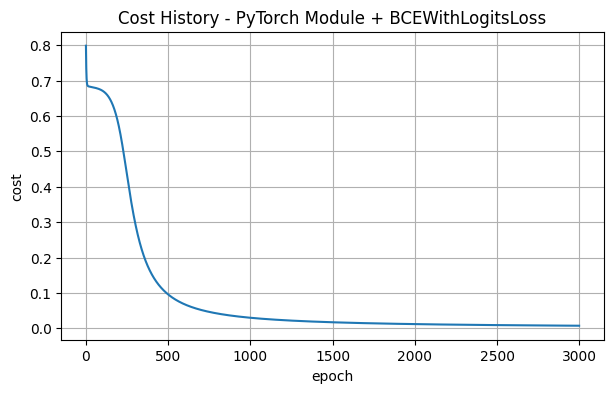

In [15]:
# 학습 후, cost가 실제로 줄었는지 숫자로 확인합니다.
print("first cost:", cost_history[0])
print("last cost:", cost_history[-1])
print("cost decreased:", cost_history[-1] < cost_history[0])

# cost 감소 그래프
plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.xlabel("epoch")
plt.ylabel("cost")
plt.title("Cost History - PyTorch Module + BCEWithLogitsLoss")
plt.grid(True)
plt.show()

In [16]:
# 학습이 끝난 model로 최종 예측을 확인합니다.
# 예측만 할 때는 gradient가 필요 없으므로 torch.no_grad()안에서 실행합니다.
with torch.no_grad():
    H_output_final = model(X_tensor)

    # BCEWithLogitsLoss 학습에서는 sigmoid를 Cost계산 전에 직접 쓰지 않았지만,
    # 사람이 볼 예측 확률을 만들 때는 sigmoid를 사용합니다.
    z_output_final = torch.sigmoid(H_output_final)

    # z_output_final은 0~1 사이의 예측확률입니다.
    # 0.5이상이면 1, 0.5미만이면 0으로 판단
    pred_final = (z_output_final >= 0.5).float()
    accuracy = (pred_final == y_tensor).float().mean()

# 결과 표 만들기
result_df = df[["temperature", "humidity", "y"]].copy()

# z_output_final은 PyTorch Tensor입니다.
# 표에 넣기 위해 단계별로 NumPy배열로 바꿉니다.
z_output_final_detached = z_output_final.detach()
z_output_final_numpy = z_output_final_detached.numpy()
z_output_final_flat = z_output_final_numpy.reshape(-1)
result_df["z_output"] = z_output_final_flat.round(4)

# pred_final도 같은 방식으로 단계별로 나눠서 넣습니다.
pred_final_detached = pred_final.detach()
pred_final_numpy = pred_final_detached.numpy()
pred_final_flat = pred_final_numpy.reshape(-1)
result_df["pred"] = pred_final_flat.astype(int)
print("accuracy:", accuracy.item())
result_df

accuracy: 1.0


,temperature,humidity,y,z_output,pred
0,10,30,0,0.0066,0
1,15,40,0,0.0102,0
2,22,50,1,0.9907,1
3,25,55,1,0.9953,1
4,28,60,1,0.9911,1
5,35,70,0,0.0072,0
6,38,80,0,0.0042,0
